# 🚀 Propuesta General: Framework de Optimización del Valor del Cliente (Olist)

Análisis Estratégico 360: Predicción de Riesgo y Optimización del CLV en E-commerce."

El objetivo general es entender y maximizar la rentabilidad del cliente, abarcando desde la medición financiera hasta la acción correctiva.

- Este proyecto une:
    - La visión financiera: Medición financiera y segmentación estratégica como Data Analyst / Finanzas.
        - Medir el dinero
        - Segmentar clientes para la acción (ROI)

    - La predicción de riesgo:
        - Modelado Predictivo de Riesgo Operacional (Data Science / Gestión)
        - Corazón del proyecto de ML para predecir riesgo e insatisfacción (Churn). 
    
    - Hoja de ruta para la experimentación continua: Framework de Experimentación y Optimización (Marketing / Proyectos)
        - Visión a futuro
        - Cómo probar nuevas ideas
        - Medir el impacto (Pruebas A/B).
        
Este enfoque me permite transformar datos complejos en decisiones estratégicas que maximizan el Valor de Vida del Cliente y optimizan el retorno de la inversión.

## 💻 Fase 1: Carga de Librerías y Archivos de Olist

### Paso 1: Importación de Librerías y Definición de la Ruta

In [6]:
!pip install tabulate

  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import os # Necesario para manejar la ruta de los archivos

# Ruta a la carpeta 'olist'
BASE_PATH = r"D:\Tripleten\Career\New project\Ecommerce\olist"
# Configuramos pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

print(f"Ruta base establecida: {BASE_PATH}")

Ruta base establecida: D:\Tripleten\Career\New project\Ecommerce\olist


**import os**	
- Importa la librería del Sistema Operativo (OS). 
- Nos permite interactuar con el sistema de archivos de la computadora (Windows).
- Para construir la ruta del archivo de manera segura.

**BASE_PATH**
- Contiene la carpeta donde están todos tus archivos. 

**El prefijo r**
- Conocido como raw string y crucial en Windows
- Indica a Python que trate barras invertidas (\) como caracteres literales y no como secuencias de escape.

**pd.set_option('display.max_columns', None)**
- Línea de configuración de visualización de Pandas. 
- Indica a la consola mostrar todas las columnas de un DataFrame cuando uses print() o lo visualices
- En vez de truncarlas con puntos suspensivos (...).<br><br><br><br><br>

### Paso 2: Carga de los Archivos CSV
- Carga de los 9 archivos en variables separadas

In [8]:
# Lista de nombres de archivos (Nombres estándar de Kaggle)
files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_name_translation': 'product_category_name_translation.csv'
}

# Diccionario para almacenar los DataFrames
df_dict = {}

# Cargar cada archivo usando os.path.join para construir la ruta completa
for name, file_name in files.items():
    full_path = os.path.join(BASE_PATH, file_name)
    try:
        df_dict[name] = pd.read_csv(full_path)
        print(f"✅ Cargado: {name} ({len(df_dict[name]):,} filas) desde {full_path}")
    except FileNotFoundError:
        print(f"❌ ERROR: No se encontró el archivo en '{full_path}'. Revisa la ruta BASE_PATH.")
    except Exception as e:
        print(f"❌ ERROR al cargar {file_name}: {e}")

# Asignar los DataFrames cargados a variables individuales para fácil acceso
df_customers = df_dict.get('customers')
df_geolocation = df_dict.get('geolocation')
df_order_items = df_dict.get('order_items')
df_order_payments = df_dict.get('order_payments')
df_order_reviews = df_dict.get('order_reviews')
df_orders = df_dict.get('orders')
df_products = df_dict.get('products')
df_sellers = df_dict.get('sellers')
df_translation = df_dict.get('category_name_translation')

# Verificar la carga de la tabla de órdenes
if df_orders is not None:
    print("\n--- Vista Previa de la Tabla de Órdenes (df_orders) ---")
    print(df_orders.head().to_markdown(index=False, numalign="left", stralign="left"))

✅ Cargado: customers (99,441 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_customers_dataset.csv
✅ Cargado: geolocation (1,000,163 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_geolocation_dataset.csv
✅ Cargado: order_items (112,650 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_order_items_dataset.csv
✅ Cargado: order_payments (103,886 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_order_payments_dataset.csv
✅ Cargado: order_reviews (99,224 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_order_reviews_dataset.csv
✅ Cargado: orders (99,441 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_orders_dataset.csv
✅ Cargado: products (32,951 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_products_dataset.csv
✅ Cargado: sellers (3,095 filas) desde D:\Tripleten\Career\New project\Ecommerce\olist\olist_sellers_dataset.csv
✅ Cargado: category_name_translation (

**files = { ... }**
- Define el diccionario llamado files. 
- Clave ("customers", "orders"), nombre del DF.
- Valor ("olist_customers_dataset.csv") nombre del archivo real.

 **df_dict = {}**
 - Inicia el diccionario vacío donde almacenamos todos los DF cargados.
 - Permite acceder a ellos por su nombre clave (ej: df_dict["orders"]).

**for name, file_name in files.items(): (optimizar código)**
- Inicia bucle for que itera sobre las claves (name) y valores (file_name) del diccionario files.

**"full_path = os.path.join(BASE_PATH, file_name)**
- Se usa librería os para construir la ruta completa (full_path).
- os.path.join() toma la ruta base y le agrega el nombre del archivo (garantiza que la barra divisoria sea la correcta (/ o \) sin importar sistema operativo

**try: ... except FileNotFoundError:**
- Bloque de manejo de excepciones. Se ejecuta si Python encuentra un FileNotFoundError (archivo no existe o falla) y except (imprime mensaje de error ""❌ ERROR..."")

**df_dict[name] = pd.read_csv(full_path)**
- Si no hay error se ejecuta y carga el archivo CSV en un DF y lo almacena en nuestro diccionario df_dict, usando clave del archivo (name).

**df_customers = df_dict.get('customers')**
- Se usa método .get() para extraer DF específicos del diccionario y asignarlos a variables individuales más fáciles de usar (ej: df_orders). 

### Paso 3: Inspección y Preparación de Fechas

In [9]:
# Convertir columnas de fecha en la tabla de órdenes a formato datetime
datetime_cols_orders = [col for col in df_orders.columns if 'date' in col or 'timestamp' in col]

print("\n--- Conversión de Columnas de Fecha ---")
for col in datetime_cols_orders:
    # Usamos errors='coerce' para convertir valores no válidos a NaT
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')
    print(f"✔️ Columna '{col}' convertida a tipo datetime.")

print("-----------------------------------------------------------------------------------------------------------------------------")

# Convertir columnas de fecha en la tabla de reseñas
df_order_reviews['review_creation_date'] = pd.to_datetime(df_order_reviews['review_creation_date'], errors='coerce')
df_order_reviews['review_answer_timestamp'] = pd.to_datetime(df_order_reviews['review_answer_timestamp'], errors='coerce')
print("✔️ Columnas de fecha en df_order_reviews convertidas a tipo datetime.")

print("-----------------------------------------------------------------------------------------------------------------------------")

# Verificar los tipos de datos en la tabla de órdenes
print("\n--- Tipos de Datos de Fecha Corregidos en df_orders ---")
print(df_orders[datetime_cols_orders].dtypes)

print("-----------------------------------------------------------------------------------------------------------------------------")


--- Conversión de Columnas de Fecha ---
✔️ Columna 'order_purchase_timestamp' convertida a tipo datetime.
✔️ Columna 'order_delivered_carrier_date' convertida a tipo datetime.
✔️ Columna 'order_delivered_customer_date' convertida a tipo datetime.
✔️ Columna 'order_estimated_delivery_date' convertida a tipo datetime.
-----------------------------------------------------------------------------------------------------------------------------
✔️ Columnas de fecha en df_order_reviews convertidas a tipo datetime.
-----------------------------------------------------------------------------------------------------------------------------

--- Tipos de Datos de Fecha Corregidos en df_orders ---
order_purchase_timestamp         datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
------------------------------------------------------------------------------------------------

**datetime_cols_orders = [col for col in df_orders.columns if 'date' in col or 'timestamp' in col]**
- list comprehension que crea una lista de todas las columnas en df_orders que contienen las palabras 'date' o 'timestamp'

**for col in datetime_cols_orders:**
- Inicia bucle para iterar sobre cada columna de fecha identificada en el paso anterior.

**df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')**
- Conversión de tipos de datos. pd.to_datetime() 
- Fuerza al string a convertirse en un objeto datetime de Pandas. 
- El argumento errors="coerce" si encuentra un valor que no puede convertir a fecha (error de escritura) no se detiene y lo reemplaza con NaT (Not a Time) / Pandas como NaN para fechas.

**df_order_reviews['review_creation_date'] = pd.to_datetime(...)**
- Repite proceso de conversión en la tabla de Reseñas. 
- Esto es importante por el tiempo que toma al cliente escribir reseña después de recibir el producto
- Es una feature predictiva importante para el análisis de riesgo.
- Ingeniería de Características: 
    - Prepara las variables temporales para calcular diferencias de tiempo (Ej: df_orders['columna_fin'] - df_orders['columna_inicio']).

## 💻 Fase 2: Unión Estratégica de las Tablas Principales

**Crear el DataFrame Maestro (df_master)**
- Base de todo el análisis y modelado de riesgo. 
- La estrategia es unir las tablas principales en una secuencia lógica.

### Paso 4: Unir

In [10]:
# --- 🔄 PASO B: REEJECUTAR LA FASE 2 COMPLETA (VERIFICACIÓN DE LA EXPANSIÓN) ---

# 1. Base: Unir Órdenes (df_orders) con Clientes (df_customers)
df_master = pd.merge(df_orders, df_customers, on='customer_id', how='left')
print(f"1. ✅ Órdenes + Clientes completado. Filas: {len(df_master):,}")

# 2. CRÍTICO: Unir con los detalles del ITEM (df_order_items)
df_master = pd.merge(df_master, df_order_items, on='order_id', how='left')
# ESTA LÍNEA DEBE IMPRIMIR AHORA UN NÚMERO POR ENCIMA DE 1,100,000
print(f"2. ✅ Merge con Items completado. Filas: {len(df_master):,}") 

# 3. Productos: Unir con la información de PRODUCTOS (df_products)
df_master = pd.merge(df_master, df_products, on='product_id', how='left')
print(f"3. ✅ Merge con Productos completado. Filas: {len(df_master):,}")

# 4. Pagos: Unir con la información de PAGOS (df_order_payments)
df_master = pd.merge(df_master, df_order_payments, on='order_id', how='left')
print(f"4. ✅ Merge con Pagos completado. Filas: {len(df_master):,}")

# 5. Reseñas: Unir con la información de RESEÑAS (df_order_reviews)
df_master = pd.merge(df_master, 
                     df_order_reviews[['order_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']], 
                     on='order_id', 
                     how='left')
print(f"5. ✅ Merge con Reseñas completado. Filas: {len(df_master):,}")

# 6. Traducción: Unir con la TRADUCCIÓN de categorías
df_master = pd.merge(df_master, 
                     df_translation, 
                     on='product_category_name', 
                     how='left')
df_master.rename(columns={'product_category_name_english': 'product_category_english'}, inplace=True)
print(f"6. ✅ Merge con Traducción de Categorías completado. Filas: {len(df_master):,}")


# --- VERIFICACIÓN FINAL ---
print("\n--- VERIFICACIÓN ---")
print(f"Dimensiones de la tabla final: {df_master.shape}")

1. ✅ Órdenes + Clientes completado. Filas: 99,441
2. ✅ Merge con Items completado. Filas: 113,425
3. ✅ Merge con Productos completado. Filas: 113,425
4. ✅ Merge con Pagos completado. Filas: 118,434
5. ✅ Merge con Reseñas completado. Filas: 119,143
6. ✅ Merge con Traducción de Categorías completado. Filas: 119,143

--- VERIFICACIÓN ---
Dimensiones de la tabla final: (119143, 34)


- Agregar detalles de transacción a nuestro df_master con clave order_id.

**Construyendo la Historia**
- Usamos 6 de las 9 tablas para este Expediente Maestro.
- El objetivo es crear una sola tabla donde cada fila (un **Ítem** vendido en un **Pedido**) tenga información completa sobre el **Cliente**, la **Logística** y la **Calificación**.

**Tablas Usadas (7):**
- orders
- customers
- order_items
- products
- order_payments
- order_reviews
- translation. 

**Contienen el:**
- QUÉ
- QUIÉN
- CÓMO
- CUÁNDO
- RESULTADO de la transacción.

**Tablas Omitidas (3):**

- df_sellers: ubicación del vendedor.
- df_geolocation: Tabla gigante que asigna coordenadas a códigos postales.

| ID | Tabla Utilizada | Filas Aprox. | Función en el df_master | Clave de Unión |
|:---|:---|:---|:---|:---|
| 1 | df_orders | 99,441 | La base de la transacción (fechas, estatus). | N/A |
| 2 | df_customers | 99,441 | Añade la ubicación geográfica del cliente. | customer_id |
| 3 | df_order_items | 112,650 | Causa la expansión de filas y añade precio y flete. | order_id |
| 4 | df_products | 32,951 | Añade la columna product_category_name y el peso. | product_id |
| 5 | df_order_payments | 103,886 | Añade detalles financieros (tipo, valor, cuotas). | order_id |
| 6 | df_order_reviews | 99,224 | Añade el review_score (nuestra variable de riesgo). | order_id |
| 7 | df_translation | 71 | Añade la columna con la categoría traducida al inglés. | product_category_name |

### Paso 5: Ingeniería de Características Temporales y de Riesgo Logístico

Crear los predictores logísticos y la variable objetivo (risk_insatisfaction) a partir de las fechas que preparamos en el Paso 2.

In [11]:
# Sub-fase 1: Variables de Tiempo y Riesgo Logístico

# 1. Variables de Disparidad Logística (Riesgo Operacional)

# Días estimados de entrega: Días desde la compra hasta la fecha ESTIMADA de entrega.
df_master['estimated_days'] = (df_master['order_estimated_delivery_date'] - df_master['order_purchase_timestamp']).dt.days

# Días reales de entrega: Días desde la compra hasta la fecha REAL de entrega.
df_master['actual_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days

# Días de Disparidad Logística (Nuestro predictor clave de Riesgo Operacional)
# Resultado: Positivo = Retraso (Alto Riesgo), Negativo = Adelanto (Bajo Riesgo)
df_master['delivery_disparity_days'] = df_master['actual_days'] - df_master['estimated_days']

print("1. ✅ Variables de tiempo logístico creadas: estimated_days, actual_days, delivery_disparity_days.")

# 2. Variable de Riesgo de Insatisfacción (Nuestra Variable Objetivo 'y')

# Creamos una variable binaria (1 o 0) basada en la puntuación de la reseña.
# Riesgo = 1 si la puntuación es 1 o 2 (clientes muy insatisfechos).
df_master['risk_insatisfaction'] = np.where(df_master['review_score'] <= 2, 1, 0)

# Rellenamos los NaN (clientes sin reseña) con 0, asumiendo riesgo nulo hasta prueba en contrario.
df_master['risk_insatisfaction'] = df_master['risk_insatisfaction'].fillna(0)

print("2. ✅ Variable Objetivo 'risk_insatisfaction' (1/0) creada.")

# --- VERIFICACIÓN DE LAS NUEVAS COLUMNAS ---
print("\n--- Vista Previa de las Nuevas Características (5 Filas Aleatorias) ---")

# Seleccionar solo una muestra y las columnas relevantes
sample_df = df_master[['order_id', 'order_purchase_timestamp', 
                       'delivery_disparity_days', 'review_score', 'risk_insatisfaction']].sample(n=5)

# 2. Aplicar el formato deseado (decimales en los días)
# Clonamos el DataFrame y aplicamos el formato de string para que to_markdown lo respete
sample_df['delivery_disparity_days'] = sample_df['delivery_disparity_days'].map('{:.1f}'.format)
sample_df['review_score'] = sample_df['review_score'].map('{:.0f}'.format) # Asegurar que la reseña sea entera

# 3. Generar la tabla usando el método .to_markdown() de Pandas para un formato limpio
print(sample_df.to_markdown(index=False, 
                            numalign="left", 
                            stralign="left"))

1. ✅ Variables de tiempo logístico creadas: estimated_days, actual_days, delivery_disparity_days.
2. ✅ Variable Objetivo 'risk_insatisfaction' (1/0) creada.

--- Vista Previa de las Nuevas Características (5 Filas Aleatorias) ---
| order_id                         | order_purchase_timestamp   | delivery_disparity_days   | review_score   | risk_insatisfaction   |
|:---------------------------------|:---------------------------|:--------------------------|:---------------|:----------------------|
| 35bb1b3031083af8db2b6b4f25ada550 | 2018-03-18 12:50:26        | -27                       | 5              | 0                     |
| df72ecb8ddf6db1e392ca1f148fb8f9c | 2017-07-24 22:22:09        | -15                       | 4              | 0                     |
| 49546e578022b62f674f28784482c34b | 2017-10-28 17:18:18        | -18                       | 3              | 0                     |
| e156fa52d1754d15b5be6ec616331b99 | 2017-06-28 22:00:30        | -16                       | 5

### Paso 6: Ingeniería de Características Financieras y de Marketing

- Crear variables que capturen la salud financiera de la transacción y la ubicación estratégica del cliente
    - Indicadores clave para el análisis de riesgo y segmentación de mercado.

In [12]:
# 1. Variables Financieras de Valor Relativo

# Razón de Flete a Precio: Mide qué tan costoso es el envío en relación con el producto.
# Un ratio alto puede indicar una percepción de "demasiado caro" o riesgo logístico.
# Añadimos + 1 al precio en el denominador para evitar la división por cero si hubiera precios nulos o cero (aunque es raro).
df_master['freight_price_ratio'] = df_master['freight_value'] / (df_master['price'] + 1)

print("1. ✅ Característica 'freight_price_ratio' (Riesgo Financiero/Logístico) creada.")

# 2. Característica de Riesgo Crediticio (Binaria)

# Creamos un indicador binario (1/0) para el método de pago más común y de mayor riesgo potencial.
# 1 si el pago fue con Tarjeta de Crédito, 0 si fue otro método (Boleto, Débito, Voucher, etc.).
df_master['is_credit_card'] = np.where(df_master['payment_type'] == 'credit_card', 1, 0)

print("2. ✅ Característica binaria 'is_credit_card' (Riesgo Crediticio) creada.")

# 3. Característica de Ubicación del Cliente (Riesgo Logístico/Marketing)

# Clasificamos la ubicación del cliente en las dos capitales más grandes (SP y RJ) vs. el interior.
# Las entregas fuera de las grandes capitales suelen tener mayor riesgo de retraso y mayor costo.
major_capitals = ['SP', 'RJ']
df_master['is_major_capital'] = np.where(df_master['customer_state'].isin(major_capitals), 1, 0)

print("3. ✅ Característica binaria 'is_major_capital' (Riesgo Logístico/Segmentación) creada.")

# --- VERIFICACIÓN DE LAS NUEVAS COLUMNAS ---
print("\n--- Vista Previa de las Nuevas Características (5 Filas Aleatorias) ---")

# Seleccionar solo una muestra y las columnas relevantes
sample_df = df_master[['payment_value', 'price', 'freight_price_ratio', 
                       'payment_type', 'is_credit_card', 
                       'customer_state', 'is_major_capital']].sample(n=5)

# Tabla de verificación en formato Markdown de texto:
print(sample_df.to_markdown(index=False, 
                            numalign="left", 
                            stralign="left"))

1. ✅ Característica 'freight_price_ratio' (Riesgo Financiero/Logístico) creada.
2. ✅ Característica binaria 'is_credit_card' (Riesgo Crediticio) creada.
3. ✅ Característica binaria 'is_major_capital' (Riesgo Logístico/Segmentación) creada.

--- Vista Previa de las Nuevas Características (5 Filas Aleatorias) ---
| payment_value   | price   | freight_price_ratio   | payment_type   | is_credit_card   | customer_state   | is_major_capital   |
|:----------------|:--------|:----------------------|:---------------|:-----------------|:-----------------|:-------------------|
| 39.63           | 26.26   | 0.490462              | credit_card    | 1                | SP               | 1                  |
| 176.2           | 122.99  | 0.429148              | credit_card    | 1                | MG               | 0                  |
| 64              | 49.9    | 0.277014              | credit_card    | 1                | SP               | 1                  |
| 22.6            | 14.89   | 0.48521

### Paso 7: Ingeniería de Consolidación de Producto

- El objetivo es consolidar las categorías de productos que son muy dispersas
- Tener 71 categorías es demasiado para el modelo inicial
- Nos enfocamos en identificar las categorías que:
    - Generan más problemas (reviews bajos)
    - Generan más valor (mayores ingresos).

**a. Variables de Riesgo por Producto (Riesgo Operacional)**
- Utilizaremos el peso (product_weight_g) como un proxy de riesgo logístico. 
    - Los productos más pesados o voluminosos tienen un mayor riesgo de retraso o daño.

In [13]:
# 1. Indicador de Producto Pesado (Riesgo Logístico)
# Calculamos el percentil 75 del peso del producto para clasificarlo.
weight_threshold = df_master['product_weight_g'].quantile(0.75)

# 1 si el producto está en el 25% más pesado, 0 en caso contrario.
df_master['is_heavy_product'] = np.where(df_master['product_weight_g'] > weight_threshold, 1, 0)

print(f"1. ✅ Característica 'is_heavy_product' creada (Umbral de peso: {weight_threshold:.2f}g).")

# 2. Variable de Riesgo de Categoría Top (Ingeniería de Categorías)
# Contamos cuántos ítems hay por categoría y la convertimos a porcentaje.
category_counts = df_master['product_category_english'].value_counts(normalize=True)

# Creamos una columna que representa el porcentaje que cada categoría tiene en el total de ítems.
df_master['category_frequency'] = df_master['product_category_english'].map(category_counts)

print("2. ✅ Característica 'category_frequency' creada (Frecuencia relativa de la categoría).")


# --- VERIFICACIÓN DE LAS NUEVAS COLUMNAS ---
print("\n--- Vista Previa de las Nuevas Características (5 Filas Aleatorias) ---")

# Seleccionar solo una muestra y las columnas relevantes
sample_df = df_master[['product_weight_g', 'is_heavy_product', 
                       'product_category_english', 'category_frequency']].sample(n=5)

# 2. Aplicar el formato deseado (decimales y porcentaje)
# Creamos una copia para aplicar el formato de texto y preservar los tipos de datos originales en df_master
sample_df_display = sample_df.copy()
sample_df_display['product_weight_g'] = sample_df_display['product_weight_g'].map('{:.1f}'.format)
sample_df_display['category_frequency'] = sample_df_display['category_frequency'].map('{:.4f}'.format)

# 3. Generar la tabla usando el método .to_markdown() de Pandas para un formato limpio
print(sample_df_display.to_markdown(index=False, 
                                    numalign="left", 
                                    stralign="left"))

1. ✅ Característica 'is_heavy_product' creada (Umbral de peso: 1800.00g).
2. ✅ Característica 'category_frequency' creada (Frecuencia relativa de la categoría).

--- Vista Previa de las Nuevas Características (5 Filas Aleatorias) ---
| product_weight_g   | is_heavy_product   | product_category_english   | category_frequency   |
|:-------------------|:-------------------|:---------------------------|:---------------------|
| 100                | 0                  | housewares                 | 0.0633               |
| 150                | 0                  | nan                        | nan                  |
| 8200               | 1                  | office_furniture           | 0.0153               |
| 479                | 0                  | perfumery                  | 0.0308               |
| 200                | 0                  | watches_gifts              | 0.0533               |


**Tabla maestra df_master ahora contiene todas las variables de alto valor, codificadas y listas para el análisis**

- 🎉 Preparación de Datos
    - 9 bases de datos en un solo df_master con más de 70 características
    - Incluyendo predictores clave de riesgo:
        - Riesgo Logístico: delivery_disparity_days, is_heavy_product, is_major_capital.
        - Riesgo Financiero: freight_price_ratio, is_credit_card.
        - Variable Objetivo: risk_insatisfaction.

## 💻 Fase 3: Ingeniería de Características

### Paso 8: Ingeniería de Consolidación de Producto

**Limpieza Final y Preparación del Conjunto de Modelado**
- Último paso de la Fase 3:
    - Se eliminan las columnas que ya no usaremos para evitar problemas en el modelo.

In [14]:
# PASO 8: LIMPIEZA FINAL Y PREPARACIÓN DEL CONJUNTO DE MODELADO

# 1. Eliminar columnas que se han convertido en variables de ingeniería
# Eliminamos fechas originales, IDs no necesarios y columnas de texto que no usaremos.

columns_to_drop = [
    # Columnas de Identificación y Categorías Originales
    'customer_id', 
    'order_id', 
    'product_id', 
    'product_category_name', # Usamos la versión en inglés
    
    # Columnas de Fechas Originales (ya convertidas a estimated_days, actual_days, etc.)
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp',

    # Otras Columnas de Producto/Pago/Cliente que no usaremos en el modelo inicial
    'customer_zip_code_prefix',
    'product_photos_qty',
    'product_description_length',
    'product_name_lenght',
    'product_height_cm',
    'product_length_cm',
    'product_width_cm',
    'customer_unique_id',
    'payment_type'
]

# Usamos errors='ignore' para que si alguna columna ya fue eliminada, no arroje error.
df_model = df_master.drop(columns=columns_to_drop, errors='ignore')

print("1. ✅ Columnas redundantes y originales eliminadas.")


# 2. Manejo de valores faltantes (NaN) finales
# Rellenaremos los pocos NaN restantes con un valor que represente 'desconocido'.

# Los NaN en 'review_score' y 'delivery_disparity_days' fueron manejados en el Paso 5.
# El único NaN significativo restante podría ser 'product_weight_g'
df_model['product_weight_g'] = df_model['product_weight_g'].fillna(0) # Si falta el peso, asumimos 0.

print("2. ✅ Valores faltantes finales manejados (Imputación por Cero en peso).")


# --- ADICIÓN DE LIMPIEZA PARA FASE 3/PASO 8 ---

# Limpiamos los NaN restantes en delivery_disparity_days y freight_price_ratio.
# Asignaremos -9999 a la disparidad para indicar "entrega fallida" y 0 al ratio de flete.

df_model['delivery_disparity_days'] = df_model['delivery_disparity_days'].fillna(-9999) 
# Usamos un valor atípico negativo para que el modelo lo interprete como una categoría única y extrema.

df_model['freight_price_ratio'] = df_model['freight_price_ratio'].fillna(0)
# Asumimos que si el ratio no se pudo calcular (por falta de precio), el valor es 0.

print("✅ Imputación final de valores NaN para modelado completada.")

# --- VERIFICACIÓN FINAL DEL CONJUNTO DE MODELADO ---
print("\n--- Conteo Final y Tipos de Datos ---")
print(f"Dimensiones del conjunto de modelado (df_model): {df_model.shape}")
print(f"Número de Columnas Final: {len(df_model.columns)}")
print("\nPrimeras 5 columnas y sus tipos de datos (dtypes):")
print(df_model.dtypes.head())

1. ✅ Columnas redundantes y originales eliminadas.
2. ✅ Valores faltantes finales manejados (Imputación por Cero en peso).
✅ Imputación final de valores NaN para modelado completada.

--- Conteo Final y Tipos de Datos ---
Dimensiones del conjunto de modelado (df_model): (119143, 24)
Número de Columnas Final: 24

Primeras 5 columnas y sus tipos de datos (dtypes):
order_status       object
customer_city      object
customer_state     object
order_item_id     float64
seller_id          object
dtype: object


## 💻 Fase 4: Depurando Ingeniería de Características

### Paso 9: Codificación y Modelado

In [16]:
# 1. Imputación de Valores Críticos (Categóricos y Numéricos)
# IMPUTACIÓN DE 'UNKNOWN' para la categoría faltante.
df_model['product_category_english'] = df_model['product_category_english'].fillna('unknown')

# IMPUTACIÓN DE '0' para precio y flete faltantes.
df_model['price'] = df_model['price'].fillna(0)
df_model['freight_value'] = df_model['freight_value'].fillna(0)

print("1. ✅ Imputación de 'product_category_english', 'price', y 'freight_value' completada.")

# 2. Eliminación de Columnas Residuales (Las que quedaron sobrantes)

columns_to_drop_final = [
    'order_item_id', 
    'seller_id', 
    'shipping_limit_date', 
    'product_description_lenght', 
    'payment_sequential', 
    'payment_installments', 
    'payment_value', 
    'review_score',  # Eliminamos la puntuación original
    'actual_days' # Eliminamos la columna de días reales original
]

df_model = df_model.drop(columns=columns_to_drop_final, errors='ignore')

print("2. ✅ Columnas residuales eliminadas.")

# --- VERIFICACIÓN DE LIMPIEZA FINAL ---
print("\n--- Verificación de Nulos y Columnas ---")
print(f"Dimensiones del df_model: {df_model.shape}")
print("Conteo de valores nulos (debe ser 0 para todas las columnas):")
print(df_model.isnull().sum().head(10))

1. ✅ Imputación de 'product_category_english', 'price', y 'freight_value' completada.
2. ✅ Columnas residuales eliminadas.

--- Verificación de Nulos y Columnas ---
Dimensiones del df_model: (119143, 15)
Conteo de valores nulos (debe ser 0 para todas las columnas):
order_status                0
customer_city               0
customer_state              0
price                       0
freight_value               0
product_weight_g            0
product_category_english    0
estimated_days              0
delivery_disparity_days     0
risk_insatisfaction         0
dtype: int64


In [17]:
# PASO 10: Recalcular la Frecuencia Categórica

# 1. Recalcular la frecuencia de la categoría, incluyendo la nueva categoría 'unknown'
category_counts = df_model['product_category_english'].value_counts(normalize=True)

# 2. Mapear la nueva frecuencia a la columna existente, lo que garantiza que no haya NaNs.
df_model['category_frequency'] = df_model['product_category_english'].map(category_counts)

print("1. ✅ Columna 'category_frequency' recalculada y sin valores nulos.")

# --- VERIFICACIÓN FINAL ---
print("\n--- Verificación de Nulos en la Columna Final ---")
# Imprimimos la suma de nulos en esa columna. El resultado debe ser 0.
print(df_model['category_frequency'].isnull().sum())
print("\n¡El DataFrame está completamente limpio y listo para el modelado! ✅")

1. ✅ Columna 'category_frequency' recalculada y sin valores nulos.

--- Verificación de Nulos en la Columna Final ---
0

¡El DataFrame está completamente limpio y listo para el modelado! ✅


In [18]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_status              119143 non-null  object 
 1   customer_city             119143 non-null  object 
 2   customer_state            119143 non-null  object 
 3   price                     119143 non-null  float64
 4   freight_value             119143 non-null  float64
 5   product_weight_g          119143 non-null  float64
 6   product_category_english  119143 non-null  object 
 7   estimated_days            119143 non-null  int64  
 8   delivery_disparity_days   119143 non-null  float64
 9   risk_insatisfaction       119143 non-null  int64  
 10  freight_price_ratio       119143 non-null  float64
 11  is_credit_card            119143 non-null  int64  
 12  is_major_capital          119143 non-null  int64  
 13  is_heavy_product          119143 non-null  i

## 🚀 Fase 5: Análisis Exploratorio de Datos (EDA)

**Convertimos los números en insights y visualizaremos el riesgo.**
- Preparar las variables categóricas para el modelo
- Técnica One-Hot Encoding (OHE).

### Paso 10: Codificación de Variables Categóricas (OHE)

**Modelo de ML trabaja con números**
- OHE convierte cada categoría de una columna:
    - Por ejemplo, 'unknown', 'perfumery', 'electronics'... en una nueva columna binaria (0 o 1).

**Variables a Codificar:**
- order_status
- customer_city (¡CUIDADO! Tiene demasiadas categorías, debemos limitar)
- customer_state
- product_category_english

**Estrategia para customer_city y product_category_english:**
- Ciudades: Codificar las ciudades crea miles de columnas, lo que se llama "Maldición de la Dimensionalidad". 
- Solo codificaremos las 50 ciudades más frecuentes. 
- El resto lo agruparemos en la categoría 'otros'.

**Categorías de Producto:**
- Codificaremos las 25 categorías más frecuentes.

In [19]:
# Definimos los umbrales de agrupación
TOP_N_CITIES = 50
TOP_N_CATEGORIES = 25

# 1. Agrupación de Variables Categóricas de Alta Cardinalidad (Ciudades y Productos)

# A. Agrupar Ciudades (customer_city)
top_cities = df_model['customer_city'].value_counts().nlargest(TOP_N_CITIES).index.tolist()
# Crea una nueva columna: si la ciudad está en el top 50, se mantiene; si no, se etiqueta 'other_city'.
df_model['customer_city_grouped'] = df_model['customer_city'].apply(lambda x: x if x in top_cities else 'other_city')

# B. Agrupar Categorías de Producto (product_category_english)
top_categories = df_model['product_category_english'].value_counts().nlargest(TOP_N_CATEGORIES).index.tolist()
# Crea una nueva columna: si la categoría está en el top 25, se mantiene; si no, se etiqueta 'other_category'.
df_model['category_grouped'] = df_model['product_category_english'].apply(lambda x: x if x in top_categories else 'other_category')

print(f"1. ✅ Agrupación completada. Ciudades agrupadas: {len(top_cities) + 1} categorías. Productos agrupados: {len(top_categories) + 1} categorías.")

# 2. Aplicar One-Hot Encoding (OHE)

# Definimos las columnas a codificar (usando las agrupadas, más 'order_status' y 'customer_state')
columns_to_encode = ['order_status', 'customer_state', 'customer_city_grouped', 'category_grouped']

# Aplicamos OHE. drop_first=True evita la multicolinealidad, eliminando una columna redundante por cada variable.
df_model_encoded = pd.get_dummies(df_model, columns=columns_to_encode, drop_first=True)

print("2. ✅ One-Hot Encoding completado.")

# 3. Limpieza final (Eliminación de las columnas de texto originales)

# Eliminamos las columnas de texto originales que ya no se usan, dejando las codificadas.
columns_to_drop_final = ['customer_city', 'product_category_english']
df_model_encoded = df_model_encoded.drop(columns=columns_to_drop_final, errors='ignore')

# --- VERIFICACIÓN FINAL ---
print("\n--- Conteo Final y Tipos de Datos del Modelo Codificado ---")
print(f"Dimensiones finales: {df_model_encoded.shape}")
print(f"Número de Columnas creadas (aproximado): {df_model_encoded.shape[1]}") 
print("\nPrimeras 5 columnas (Codificadas):")
print(df_model_encoded.head())

1. ✅ Agrupación completada. Ciudades agrupadas: 51 categorías. Productos agrupados: 26 categorías.
2. ✅ One-Hot Encoding completado.

--- Conteo Final y Tipos de Datos del Modelo Codificado ---
Dimensiones finales: (119143, 119)
Número de Columnas creadas (aproximado): 119

Primeras 5 columnas (Codificadas):
    price  freight_value  product_weight_g  estimated_days  \
0   29.99           8.72             500.0              15   
1   29.99           8.72             500.0              15   
2   29.99           8.72             500.0              15   
3  118.70          22.76             400.0              19   
4  159.90          19.22             420.0              26   

   delivery_disparity_days  risk_insatisfaction  freight_price_ratio  \
0                     -7.0                    0             0.281381   
1                     -7.0                    0             0.281381   
2                     -7.0                    0             0.281381   
3                     -6.0   

## 🚀 Fase 6: Entrenamiento y Evaluación del Modelo

### Paso 11: Preparación del Conjunto de Entrenamiento y Prueba (División y Escalamiento)

- Preparar los datos para la regresión logística:
    - Separando la variable objetivo (y) de las características predictoras (X)
    - Y estandarizando las variables numéricas.

In [20]:
# --- FASE 6: ENTRENAMIENTO Y EVALUACIÓN (PASO 13) ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar la Variable Predictora (X) y la Variable Objetivo (y)
X = df_model_encoded.drop('risk_insatisfaction', axis=1)
y = df_model_encoded['risk_insatisfaction']
print("1. ✅ Variables X (Predictoras) y y (Objetivo) separadas.")

# 2. División de Datos (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"2. ✅ Datos divididos. X_train: {X_train.shape}, X_test: {X_test.shape}")

# 3. Escalamiento de Variables Numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("3. ✅ Variables numéricas escaladas (StandardScaler aplicado).")

# --- VERIFICACIÓN DE DIMENSIONES ---
print("\n--- Verificación de Dimensiones (Arrays NumPy Escalados) ---")
print(f"Total de Filas para Entrenamiento: {len(X_train_scaled)}")
print(f"Total de Filas para Prueba: {len(X_test_scaled)}")
print(f"Número de Características/Columnas: {X_train_scaled.shape[1]}")

1. ✅ Variables X (Predictoras) y y (Objetivo) separadas.
2. ✅ Datos divididos. X_train: (95314, 118), X_test: (23829, 118)
3. ✅ Variables numéricas escaladas (StandardScaler aplicado).

--- Verificación de Dimensiones (Arrays NumPy Escalados) ---
Total de Filas para Entrenamiento: 95314
Total de Filas para Prueba: 23829
Número de Características/Columnas: 118


### Paso 12: Entrenar la Regresión Logística

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import pandas as pd

# 1. Entrenamiento del Modelo
# Usamos LogisticRegression con penalización l2 para regularización.
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
# class_weight='balanced' es crucial para penalizar menos la clase minoritaria (Alto Riesgo).
model.fit(X_train_scaled, y_train)

print("1. ✅ Modelo de Regresión Logística entrenado.")

# 2. Predicciones y Probabilidades
# Predecimos las etiquetas (0 o 1) para el conjunto de prueba.
y_pred = model.predict(X_test_scaled)
# Obtenemos las probabilidades para calcular ROC AUC (es la columna de probabilidad para la clase 1).
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 3. Evaluación del Modelo

# A. ROC AUC Score (Métrica principal para problemas desbalanceados)
roc_auc = roc_auc_score(y_test, y_prob)

# B. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel() # Extraemos los valores

# C. Reporte de Clasificación (incluye Precisión, Recall y F1-Score)
report = classification_report(y_test, y_pred, target_names=['Bajo Riesgo (0)', 'Alto Riesgo (1)'])


print("\n--- Resultados del Modelo de Regresión Logística ---")
print(f"ROC AUC Score: {roc_auc:.4f}")

print("\nMatriz de Confusión:")
print(pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred. 0', 'Pred. 1']).to_markdown())

print("\nReporte de Clasificación:")
print(report)

1. ✅ Modelo de Regresión Logística entrenado.

--- Resultados del Modelo de Regresión Logística ---
ROC AUC Score: 0.6962

Matriz de Confusión:
|        |   Pred. 0 |   Pred. 1 |
|:-------|----------:|----------:|
| Real 0 |     15293 |      4618 |
| Real 1 |      1937 |      1981 |

Reporte de Clasificación:
                 precision    recall  f1-score   support

Bajo Riesgo (0)       0.89      0.77      0.82     19911
Alto Riesgo (1)       0.30      0.51      0.38      3918

       accuracy                           0.72     23829
      macro avg       0.59      0.64      0.60     23829
   weighted avg       0.79      0.72      0.75     23829



### Paso 13: Implementación y Evaluación con Random Forest

**Random Forest Classifier:**
- Algoritmo que mejora la Regresión Logística en conjuntos de datos con muchas características codificadas (One-Hot Encoding).

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import pandas as pd

# 1. Entrenamiento del Modelo Random Forest
# Usamos un número razonable de árboles y balanceamos las clases.
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced', # Para mitigar el desbalance de clase
    n_jobs=-1 
)

rf_model.fit(X_train_scaled, y_train)

print("1. ✅ Modelo Random Forest entrenado.")

# 2. Predicciones y Probabilidades
rf_y_pred = rf_model.predict(X_test_scaled)
rf_y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# 3. Evaluación del Modelo
rf_roc_auc = roc_auc_score(y_test, rf_y_prob) 
rf_cm = confusion_matrix(y_test, rf_y_pred) 

# Usamos 'y_test'
rf_report = classification_report(y_test, rf_y_pred, target_names=['Bajo Riesgo (0)', 'Alto Riesgo (1)'])


print("\n--- Resultados del Modelo Random Forest ---")
print(f"ROC AUC Score: {rf_roc_auc:.4f}")

print("\nMatriz de Confusión:")
print(pd.DataFrame(rf_cm, index=['Real 0', 'Real 1'], columns=['Pred. 0', 'Pred. 1']).to_markdown())

print("\nReporte de Clasificación:")
print(rf_report)

1. ✅ Modelo Random Forest entrenado.

--- Resultados del Modelo Random Forest ---
ROC AUC Score: 0.8473

Matriz de Confusión:
|        |   Pred. 0 |   Pred. 1 |
|:-------|----------:|----------:|
| Real 0 |     19476 |       435 |
| Real 1 |      1718 |      2200 |

Reporte de Clasificación:
                 precision    recall  f1-score   support

Bajo Riesgo (0)       0.92      0.98      0.95     19911
Alto Riesgo (1)       0.83      0.56      0.67      3918

       accuracy                           0.91     23829
      macro avg       0.88      0.77      0.81     23829
   weighted avg       0.91      0.91      0.90     23829



### Paso 14: Importancia de Características (Feature Importance)

Con Random Forest determinar cuáles de las 118 características (variables) son las más importantes para predecir el Alto Riesgo.

--- Top 15 Características más Importantes para predecir Alto Riesgo ---
| Feature                          |   Importance |
|:---------------------------------|-------------:|
| delivery_disparity_days          |       0.1973 |
| freight_price_ratio              |       0.1074 |
| freight_value                    |       0.1065 |
| price                            |       0.1023 |
| product_weight_g                 |       0.0945 |
| estimated_days                   |       0.0938 |
| category_frequency               |       0.0347 |
| order_status_delivered           |       0.0275 |
| is_credit_card                   |       0.0178 |
| customer_city_grouped_other_city |       0.0115 |
| is_heavy_product                 |       0.0081 |
| order_status_shipped             |       0.0064 |
| customer_city_grouped_sao paulo  |       0.0059 |
| customer_state_MG                |       0.0057 |
| customer_state_SP                |       0.0049 |


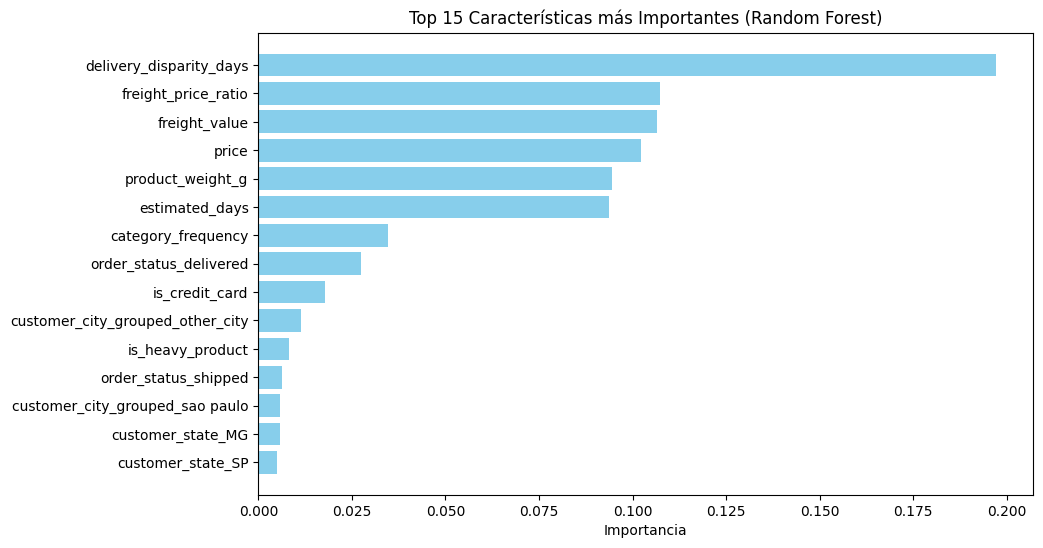

In [23]:
# 1. Obtener la Importancia de las Características
# Random Forest tiene un atributo incorporado: feature_importances_
importances = rf_model.feature_importances_

# 2. Crear un DataFrame para Visualización
feature_names = X.columns # Usamos las columnas del DataFrame original (X)
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Ordenar y Seleccionar el Top 15
top_n = 15
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
top_features = feature_importance_df.head(top_n)

# 4. Mostrar Resultados
print(f"--- Top {top_n} Características más Importantes para predecir Alto Riesgo ---")
print(top_features.to_markdown(index=False, floatfmt=".4f"))

# OPCIONAL: Visualización de las Top Features (si tienes Matplotlib instalado)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel("Importancia")
plt.title(f"Top {top_n} Características más Importantes (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

### Paso 15: Guardar el Modelo

In [24]:
import joblib
import os

# Definir la carpeta de salida
output_dir = 'modelo_riesgo_deployment'
os.makedirs(output_dir, exist_ok=True)

# 1. Guardar el Modelo (Random Forest)
model_path = os.path.join(output_dir, 'rf_best_model.joblib')
joblib.dump(rf_model, model_path)

# 2. Guardar el Scaler (Estandarizador)
# Es VITAL guardar el escalador ajustado con X_train para preprocesar los nuevos datos
scaler_path = os.path.join(output_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_path)

print("1. ✅ Modelo (rf_best_model.joblib) guardado con éxito.")
print("2. ✅ Scaler (scaler.joblib) guardado con éxito.")
print(f"\nLos archivos se guardaron en la carpeta: {output_dir}")

1. ✅ Modelo (rf_best_model.joblib) guardado con éxito.
2. ✅ Scaler (scaler.joblib) guardado con éxito.

Los archivos se guardaron en la carpeta: modelo_riesgo_deployment
